# 01 · What are behavior trees?

## Learning objectives

- Separate a decision from a behavior.
- Explain a tick, a tree node, and the three execution results.
- Read a colored execution trace without a BT library.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

Imagine a doorbell. “Is someone outside?” is a **condition**: a question about the world.
“Open the door” is an **action**: work that changes the world. A **behavior** is one such
unit of decision or work. A behavior tree arranges behaviors so a decision can be revisited.

A **node** is a behavior or a rule that coordinates other nodes. An **edge** links a parent
node to a child. The topmost node is the **root**. A **tick** is a request to do a small amount
of work and report progress. Ticking is not the same as finishing.

| Result | Meaning | Color |
|---|---|---|
| SUCCESS | This invocation achieved its goal | Green |
| FAILURE | This invocation could not achieve its goal | Red |
| RUNNING | Work remains; ask again later | Yellow |

Gray means inactive, not a fourth execution result. Failure is information, not necessarily
an exception. Repeated ticks let a controller respond to a changing world.

## Minimal working example
We first need only a function. Each call is one tick. The counter stands in for a small
piece of work; it is deliberately visible rather than hidden in a framework.

In [2]:
progress = 0

def open_door():
    global progress
    progress += 1
    return "SUCCESS" if progress >= 3 else "RUNNING"

results = [open_door() for _ in range(3)]
print(results)
assert results == ["RUNNING", "RUNNING", "SUCCESS"]

['RUNNING', 'RUNNING', 'SUCCESS']


## Step-by-step implementation
On tick 1, work starts. Tick 2 advances it. Tick 3 completes it. The caller gets control
back after every tick. A real action would inspect a motor or a future instead of a counter.
A one-node tree is already a tree: it has a root and no edges.

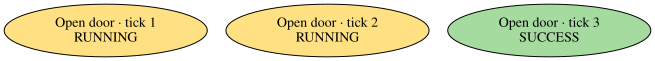

In [3]:
from graphviz import Digraph
colors = {"SUCCESS": "#a6dba0", "RUNNING": "#ffe082"}
graph = Digraph()
for tick, result in enumerate(results, 1):
    graph.node(str(tick), f"Open door · tick {tick}\n{result}",
               style="filled", fillcolor=colors[result])
display(graph)

## Interactive demonstration
Change the amount of work. Re-executing this cell rebuilds the state. The slider never
runs a background thread.

In [4]:
import ipywidgets as widgets

@widgets.interact(required=(1, 6))
def door_trace(required=3):
    for tick in range(1, required + 1):
        print(tick, "SUCCESS" if tick == required else "RUNNING")

interactive(children=(IntSlider(value=3, description='required', max=6, min=1), Output()), _dom_classes=('widg…

## Key observations

A tick returns promptly. RUNNING keeps work alive across ticks. A tree is a decision structure, not a separate thread.

## Exercises

1. Add a jammed-door condition returning FAILURE.
2. Why would sleeping for ten seconds inside a tick reduce responsiveness?

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 01).

## Summary

We can describe work using three outcomes. Next we will give these outcomes names and combine small behaviors.